In [92]:
from glob import glob
import pandas as pd
import os
from tqdm import tqdm as tqdm 
from IPython.display import Image
from pathlib import Path
# import imageio
# import moviepy.video.io.ImageSequenceClip
from tqdm import tqdm
import h5py
import math
import matplotlib
# matplotlib.use('Agg') # Must be before importing matplotlib.pyplot or pylab!
import matplotlib.pyplot as plt
import copy
import numpy as np
import os
import json
import scipy.stats
import time
from types import SimpleNamespace
import random
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

In [93]:
# !pip install seaborn

In [94]:
# cat /storage/czw/neuroprobe/data/vanilla_eval_results_lite_WithinSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/population_btbank10_0_delta_volume.json

In [95]:
ls /storage/czw/BrainBERTNeuroprobe/BrainBERT/vanilla_brainbert_eval_results_SS_SM/brainbert_keepall/

ls: cannot access '/storage/czw/BrainBERTNeuroprobe/BrainBERT/vanilla_brainbert_eval_results_SS_SM/brainbert_keepall/': No such file or directory


In [96]:
cat /storage/czw/BrainBERTNeuroprobe/BrainBERT/vanilla_brainbert_eval_results_SS_SM/brainbert_keepall/population_btbank10_0_frame_brightness.json

cat: /storage/czw/BrainBERTNeuroprobe/BrainBERT/vanilla_brainbert_eval_results_SS_SM/brainbert_keepall/population_btbank10_0_frame_brightness.json: No such file or directory


In [97]:
results_dirs = {"/storage/czw/neuroprobe/data/vanilla_eval_results_lite_WithinSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/": "Linear: Vanilla",
                "/storage/czw/neuroprobe/data/random_seed_0_results_lite_WithinSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/": "Linear: Random seed 0",
                # "/storage/czw/BrainBERTNeuroprobe/BrainBERT/vanilla_brainbert_eval_results_SS_SM/brainbert_keepall/": "brainbert: random seed 0",
                "/storage/czw/neuroprobe/data/anatomical_seed_0_results_lite_WithinSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/": "Linear: Anatomical random seed 0"}

In [98]:


def get_test_results(results, eval_name):
    eval_results = results["evaluation_results"]
    assert len(eval_results.keys()) == 1
    records = []
    for subject_trial in eval_results:
        subject = subject_trial.split("_")[0][len("btbank"):]
        trial = subject_trial.split("_")[1]
        # subject_trial_results = eval_results[subject_trial]['electrode']
        subject_trial_results = eval_results[subject_trial]['population']
        # for electrode in subject_trial_results:
        electrode_results = subject_trial_results
        time_bin_results = electrode_results["one_second_after_onset"]
        # for time_bin in time_bin_results:
        # time_bin_start = time_bin['one_second_after_onset']
        fold_results = time_bin_results['folds']
        avg_test = np.mean([f['test_roc_auc'] for f in fold_results])
        records.append({
            "subject": subject,
            "trial": trial,
            "ID": f'sub_{subject}',
            # "electrode": electrode,
            "avg_test": avg_test,
            # "time_bin": time_bin_start,
            "task": eval_name
        })
        return records



In [99]:
all_records = []

for results_root, results_name in results_dirs.items():
    
    # results_root = f"/storage/czw/neuroprobe/data/{results_dir}/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/"
    all_results_paths = glob(os.path.join(results_root, "*"))
    for path in tqdm(all_results_paths):
        name = Path(path).stem
        sub_id = name.split("_")[1][len("btbank"):]
        trial_id = name.split("_")[2]
        eval_name = "_".join(name.split("_")[3:])
        with open(path, "r") as f:
            results = json.load(f)
            test_results = get_test_results(results, eval_name)
        for record in test_results:
            record["exp"] = results_name
        all_records += test_results
        
results_df = pd.DataFrame.from_records(all_records)



100%|███████████████████| 180/180 [00:00<00:00, 5566.26it/s]


In [100]:
results_df.head()

,subject,trial,ID,avg_test,task,exp
0,7,1,sub_7,0.613779,global_flow,Linear: Vanilla
1,7,0,sub_7,0.521154,gpt2_surprisal,Linear: Vanilla
2,7,1,sub_7,0.523145,frame_brightness,Linear: Vanilla
3,10,0,sub_10,0.808199,word_index,Linear: Vanilla
4,2,0,sub_2,0.625089,word_part_speech,Linear: Vanilla


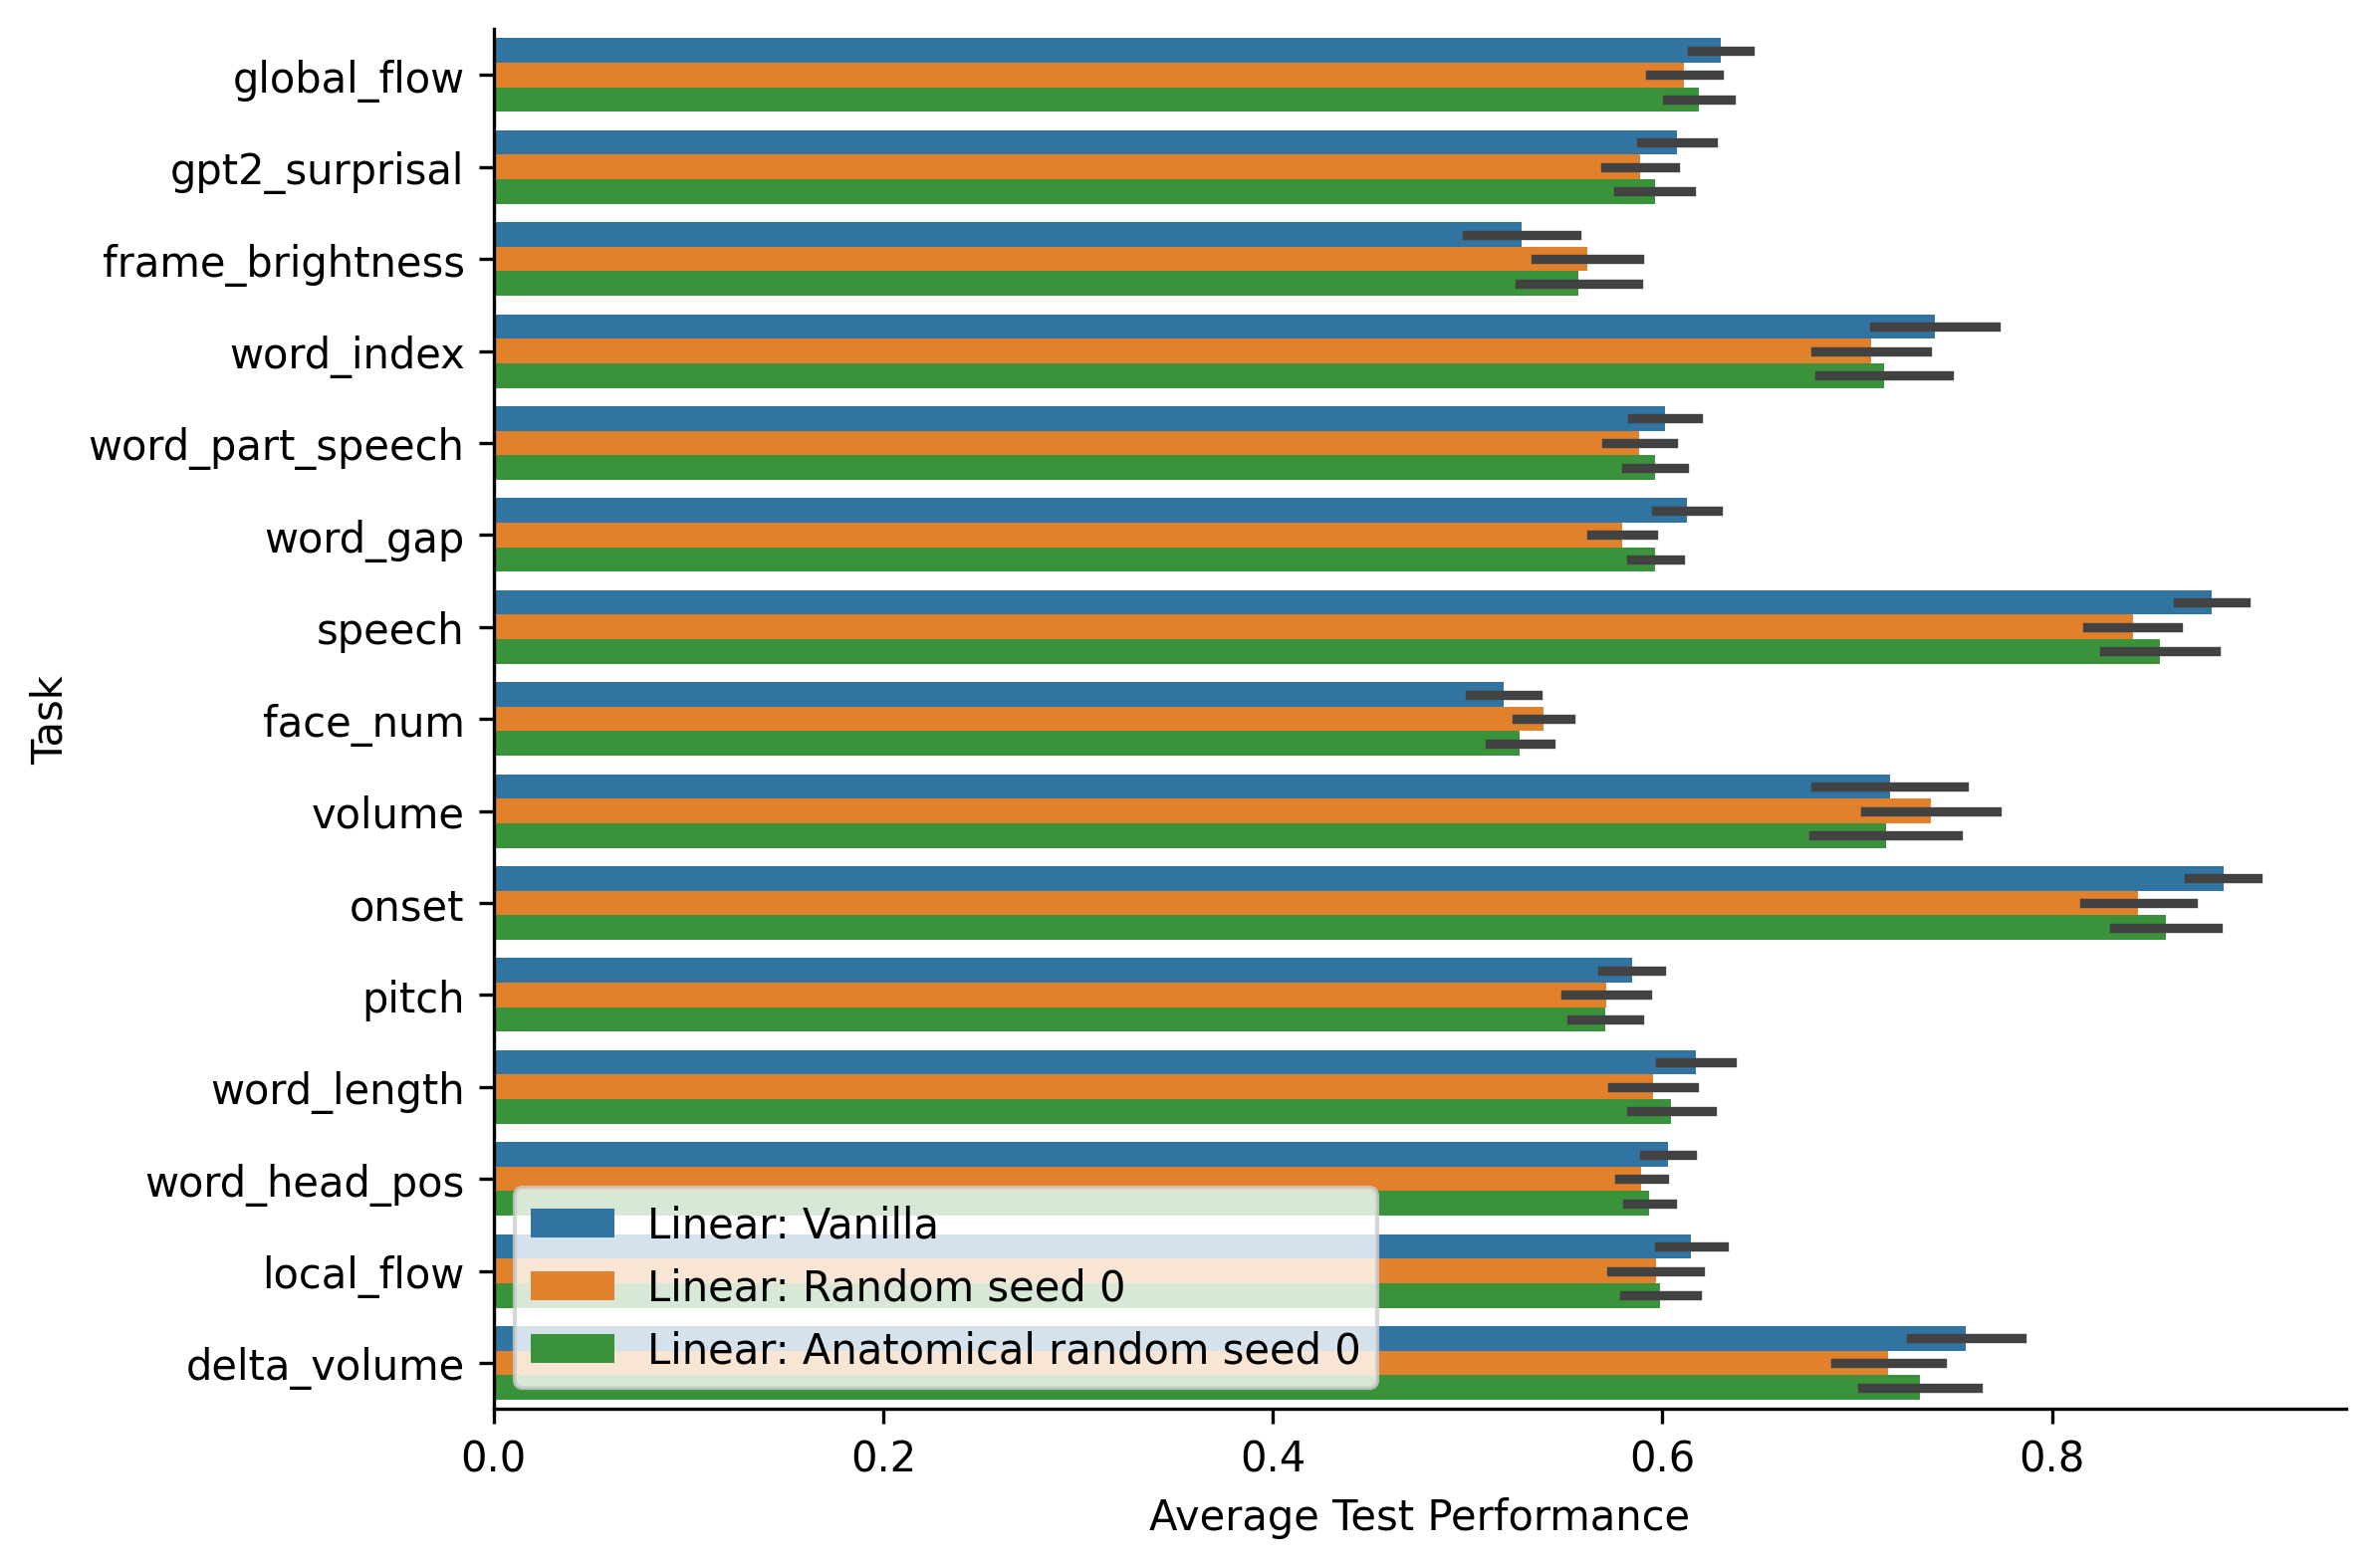

In [101]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
sns.barplot(data=results_df, y="task", hue="exp", x="avg_test", errorbar="se")
ax.set_xlabel('Average Test Performance')
ax.set_ylabel('Task')
ax.legend(loc='lower left').set_title('')
sns.despine()

In [102]:
results_df

,subject,trial,ID,avg_test,task,exp
0,7,1,sub_7,0.613779,global_flow,Linear: Vanilla
1,7,0,sub_7,0.521154,gpt2_surprisal,Linear: Vanilla
2,7,1,sub_7,0.523145,frame_brightness,Linear: Vanilla
3,10,0,sub_10,0.808199,word_index,Linear: Vanilla
4,2,0,sub_2,0.625089,word_part_speech,Linear: Vanilla
...,...,...,...,...,...,...
535,4,0,sub_4,0.474946,pitch,Linear: Anatomical random seed 0
536,3,0,sub_3,0.647375,local_flow,Linear: Anatomical random seed 0
537,2,0,sub_2,0.622154,word_gap,Linear: Anatomical random seed 0
538,4,0,sub_4,0.587474,local_flow,Linear: Anatomical random seed 0


In [136]:
NEUROPROBE_TASKS_MAPPING = {
    'onset': 'Sentence Onset',
    'speech': 'Speech',
    'volume': 'Volume', 
    'delta_volume': 'Delta Volume',
    'pitch': 'Voice Pitch',

    'word_index': 'Word Position',
    'word_gap': 'Inter-word Gap',
    'gpt2_surprisal': 'GPT-2 Surprisal',
    'word_head_pos': 'Head Word Position',
    'word_part_speech': 'Part of Speech',

    'word_length': 'Word Length',
    'global_flow': 'Global Optical Flow',
    'local_flow': 'Local Optical Flow',
    'frame_brightness': 'Frame Brightness',
    'face_num': 'Number of Faces',
}

In [140]:
results_df.task = [NEUROPROBE_TASKS_MAPPING[x] for x in results_df.task]
mean_df = results_df.pivot_table(index=["task"], columns="exp", values=["avg_test"], aggfunc="mean")
mean_df.columns = mean_df.columns.get_level_values(1)
std_df = results_df.pivot_table(index=["task"], columns="exp", values=["avg_test"], aggfunc="std")
std_df.columns = std_df.columns.get_level_values(1)


In [141]:
print((mean_df.round(2).astype(str) + "±" + std_df.round(2).astype(str)).to_markdown())

| task                | Linear: Anatomical random seed 0   | Linear: Random seed 0   | Linear: Vanilla   |
|:--------------------|:-----------------------------------|:------------------------|:------------------|
| Delta Volume        | 0.73±0.1                           | 0.72±0.09               | 0.76±0.1          |
| Frame Brightness    | 0.56±0.11                          | 0.56±0.09               | 0.53±0.1          |
| GPT-2 Surprisal     | 0.6±0.06                           | 0.59±0.06               | 0.61±0.06         |
| Global Optical Flow | 0.62±0.06                          | 0.61±0.06               | 0.63±0.05         |
| Head Word Position  | 0.59±0.04                          | 0.59±0.04               | 0.6±0.04          |
| Inter-word Gap      | 0.6±0.04                           | 0.58±0.06               | 0.61±0.05         |
| Local Optical Flow  | 0.6±0.07                           | 0.6±0.08                | 0.61±0.06         |
| Number of Faces     | 0.53±0.05    

# plot label randomization

In [144]:
results_dirs = {"/storage/czw/neuroprobe/data/vanilla_eval_results_lite_WithinSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/": "Linear: Vanilla",
                "/storage/czw/neuroprobe/data/labels_random_seed_0_results_lite_WithinSession/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/": "Linear: Labels random seed 0",
               }

In [145]:
all_records = []

for results_root, results_name in results_dirs.items():
    
    # results_root = f"/storage/czw/neuroprobe/data/{results_dir}/linear_laplacian-stft_abs_nperseg512_poverlap0.75_maxfreq150/"
    all_results_paths = glob(os.path.join(results_root, "*"))
    for path in tqdm(all_results_paths):
        name = Path(path).stem
        sub_id = name.split("_")[1][len("btbank"):]
        trial_id = name.split("_")[2]
        eval_name = "_".join(name.split("_")[3:])
        with open(path, "r") as f:
            results = json.load(f)
            test_results = get_test_results(results, eval_name)
        for record in test_results:
            record["exp"] = results_name
        all_records += test_results
        
results_df = pd.DataFrame.from_records(all_records)



100%|███████████████████| 180/180 [00:00<00:00, 4793.55it/s]


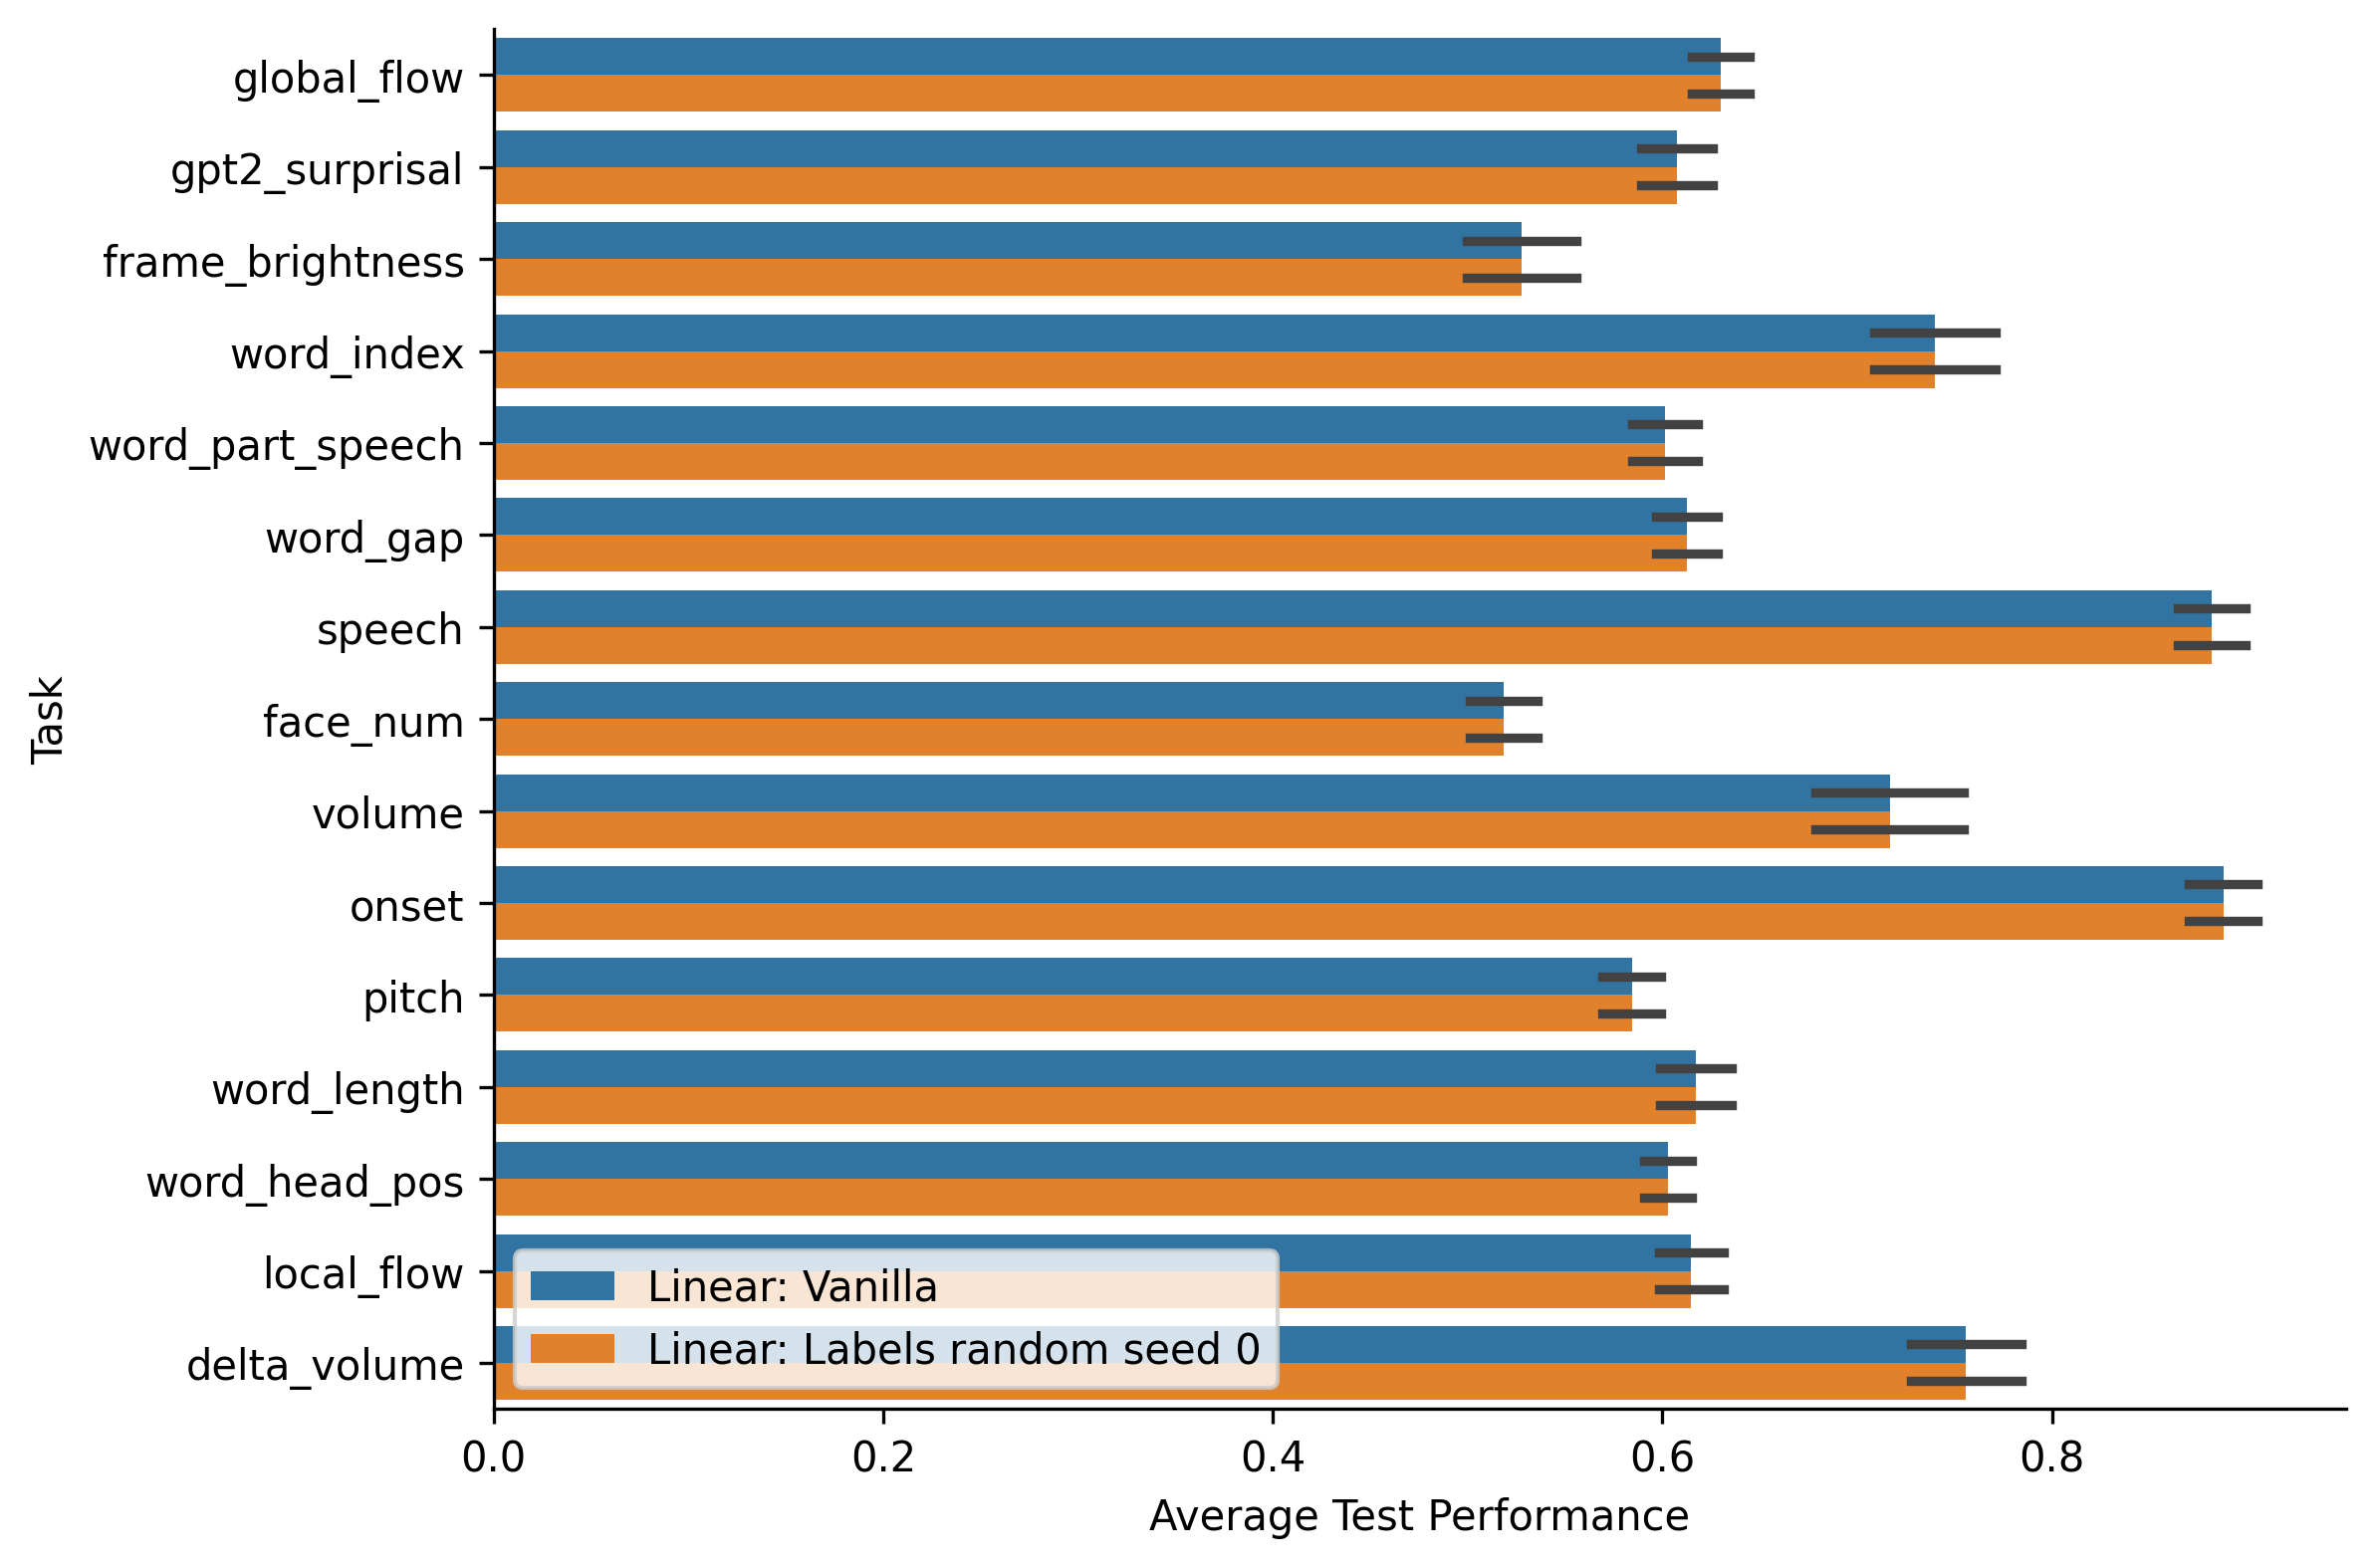

In [146]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
sns.barplot(data=results_df, y="task", hue="exp", x="avg_test", errorbar="se")
ax.set_xlabel('Average Test Performance')
ax.set_ylabel('Task')
ax.legend(loc='lower left').set_title('')
sns.despine()

In [ ]:
#